# Introduzione - Computer Vision
Esercizi del capitolo "Info e Introduzione" (8 esercizi)

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1: Separazione e Visualizzazione dei Canali RGB

Obiettivo: Dividere un'immagine nei suoi tre canali RGB e visualizzarli
separatamente (Lena.png)
- Carica un’immagine a colori con OpenCV
- Dividere l’immagine nei 3 canali
- Visualizzarli separatamente tramite la libreria matplotlib



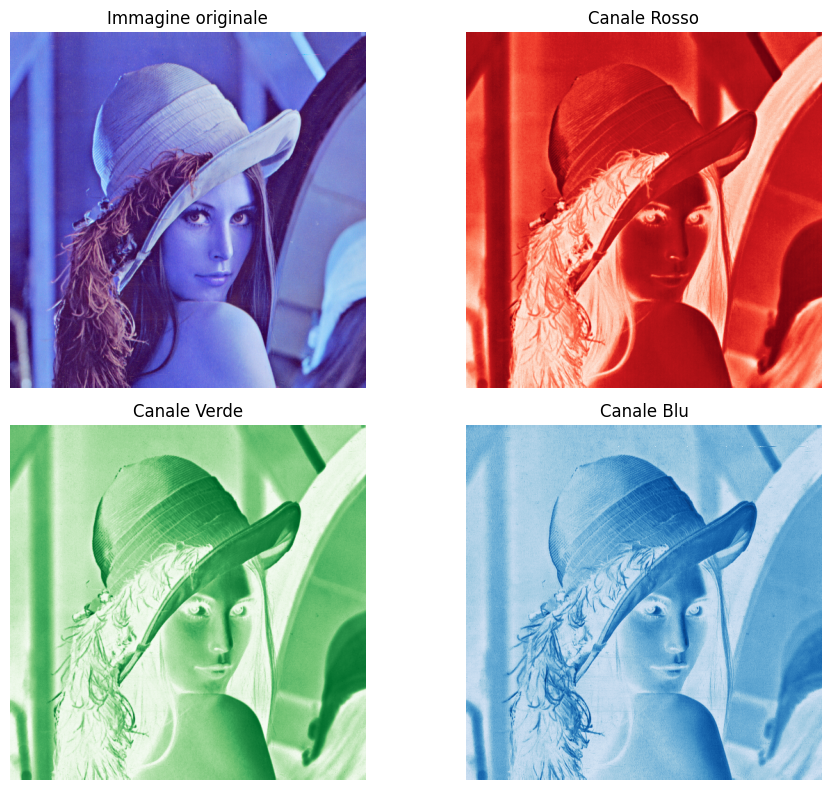

In [ ]:
path = '/content/drive/MyDrive/Computer Vision/Lenna.png'
image = cv2.imread(path)
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

r, g, b = cv2.split(rgb)

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.imshow(image)
plt.title("Immagine originale")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(r, cmap="Reds")
plt.title("Canale Rosso")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(g, cmap="Greens")
plt.title("Canale Verde")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(b, cmap="Blues")
plt.title("Canale Blu")
plt.axis("off")

plt.tight_layout()
plt.show()

## 2: Calcolo e visualizzazione dell’istogramma
Obiettivo: Calcolare e visualizzare l'istogramma di ciascun canale di
un'immagine a colori (Lena.png)
- Carica un’immagine a colori con OpenCV
- Calcola l’istogramma per ogni canale usando usando sempre OpenCV
- Visualizzarli gli istogrammi tramite la libreria matplotlib

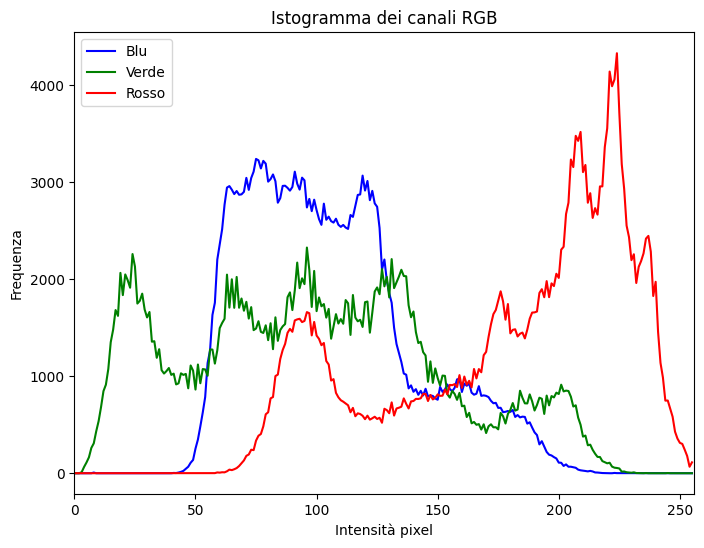

In [ ]:
path = '/content/drive/MyDrive/Computer Vision/Lenna.png'
image = cv2.imread(path)

blue = cv2.calcHist([image], [0], None, [256], [0, 256])
green = cv2.calcHist([image], [1], None, [256], [0, 256])
red = cv2.calcHist([image], [2], None, [256], [0, 256])

plt.figure(figsize=(8, 6))
plt.title("Istogramma dei canali RGB")
plt.xlabel("Intensità pixel")
plt.ylabel("Frequenza")

plt.plot(blue, color="blue", label="Blu")
plt.plot(green, color="green", label="Verde")
plt.plot(red, color="red", label="Rosso")

plt.xlim([0, 256])
plt.legend()
plt.show()

## 3: Trasformazione del Colore e Soglia di Segmentazione
Obiettivo: Convertire un'immagine a colori nello spazio colore HSV e applicare una soglia per segmentare un colore specifico (Lena.png)

- Carica un’immagine a colori con OpenCV
- Converti l'immagine dallo spazio colore RGB a HSV (cv2.cvtColor(…))
- Definisci un intervallo di valori di H, S, e V per segmentare un colore specifico (es. rosso)
  - Low_red = np.array([0, 120, 70])
  - Upper_red = np.array([10, 255, 255])
- Applica una maschera per estrarre solo le regioni dell'immagine che corrispondono al colore scelto
- Funzioni utili:
  - Cv2.inRange(…)
  - Cv2.bitwise_and(…)
- Visualizza l'immagine originale e l'immagine segmentata

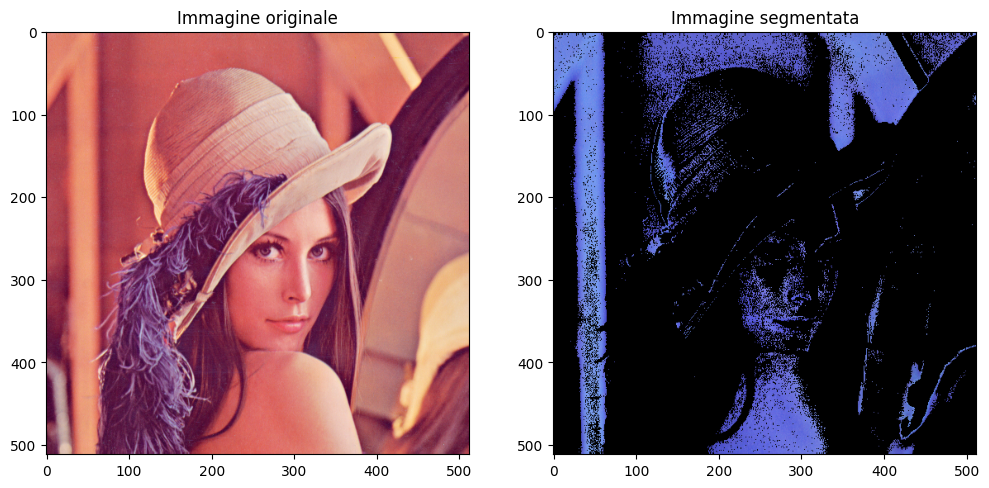

In [ ]:
path = '/content/drive/MyDrive/Computer Vision/Lenna.png'
image = cv2.imread(path)
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

red_low = np.array([0, 120, 70])
red_upper = np.array([10, 255, 255])

mask = cv2.inRange(hsv, red_low, red_upper)
result = cv2.bitwise_and(rgb, rgb, mask=mask)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Immagine originale")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Immagine segmentata")

plt.show()

## 4: Rimozione dello sfondo e sovrapposizione
Obiettivo: Rimuovere lo sfondo da un'immagine e sovrapporre l'immagine foreground su un nuovo sfondo (redSphere.png e whiteBlack.png)

- Carica un'immagine che contenga un oggetto in primo piano e uno sfondo
(ad esempio, un ritratto su uno sfondo uniforme)
- Converti l'immagine in scala di grigi e applica una soglia per ottenere una
maschera binaria che separi il primo piano dallo sfondo
- Utilizza la maschera per estrarre il primo piano e sovrapporlo su un nuovo
sfondo (un'immagine di sfondo a tua scelta)
- Visualizza l'immagine risultante (sfruttare le operazioni cv2.bitwise_...)

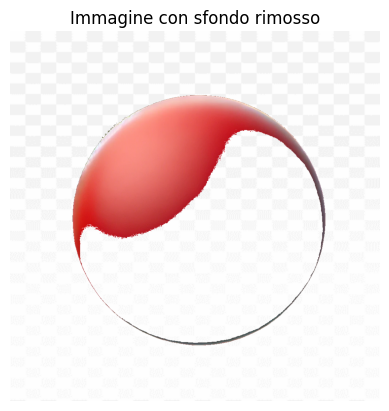

In [ ]:
path_f = '/content/drive/MyDrive/Computer Vision/redSphere.png'
path_b = '/content/drive/MyDrive/Computer Vision/whiteBack.png'
foreground = cv2.imread(path_f)
background = cv2.imread(path_b)

background = cv2.resize(background, (foreground.shape[1], foreground.shape[0]))

# Conversione dell'immagini in scala di grigi
gray = cv2.cvtColor(foreground, cv2.COLOR_BGR2GRAY)
_, mask = cv2.threshold(gray, 70, 255, cv2.THRESH_BINARY)

mask_inv = cv2.bitwise_not(mask)

fg = cv2.bitwise_and(foreground, foreground, mask=mask)
bg = cv2.bitwise_and(background, background, mask=mask_inv)

result = cv2.add(bg, fg)

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title('Immagine con sfondo rimosso')
plt.axis('off')
plt.show()

## 5: Rilevamento dei Contorni e Annotazione
Obiettivo: Rilevare i contorni di un oggetto in un'immagine e annotare l'immagine con i contorni e le aree (redSphere.png)

- Carica un’immagine e convertila in scala di grigi
- Applica un filtro di sfocatura per ridurre il rumore
- Usare un algoritmo di rilevazione contorni per estrarre i contorni
dell’immagine (cv2.canny(…), cv2.findContours(…), cv2.drawContours(…))
- Trovare e annotare le aree dei contorni (usa OpenCV)
- Visualizzare l’immagine con i contorni annotati

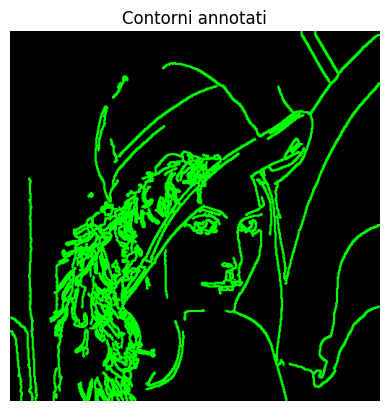

In [ ]:
path = '/content/drive/MyDrive/Computer Vision/Lenna.png'
image = cv2.imread(path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Applicazione di un filtro di sfocatura per la riduzione del rumore
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Algoritmo Canny per il rilevamento dei bordi
edges = cv2.Canny(blurred, 50, 150)
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

contour_image = cv2.drawContours(np.zeros_like(image), contours, -1, (0, 255, 0), 2)

plt.imshow(cv2.cvtColor(contour_image, cv2.COLOR_BGR2RGB))
plt.title('Contorni annotati')
plt.axis('off')
plt.show()

## 6: Applicazione delle operazioni morfologiche di dilatazione ed erosione
Obiettivo: Rimuovere il rumore da maschere binarie (gatto.png)

- Carica e Preprocessa l’Immagine:
  - Carica immagine a colori
  - Convertila in scala di grigi
- Segmenta
  - Segmenta l’immagine applicando un filtro sogliatura
  - Crea una maschera binaria per le aree rilevate
- Denoise:
  - Applicazione di dilate-erode e visualizza
  - Applicazione di erode-dilate e visualizza

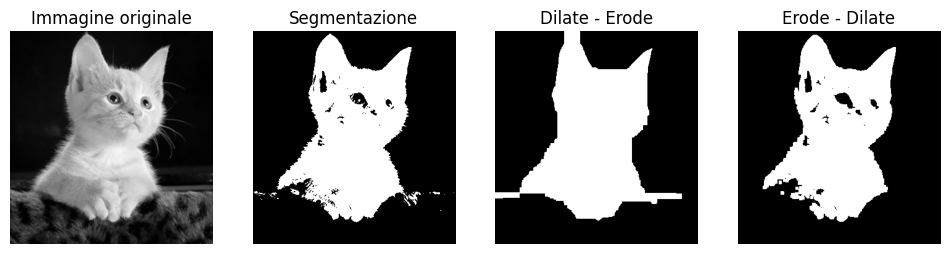

In [ ]:
path = '/content/drive/MyDrive/Computer Vision/gatto.png'
image = cv2.imread(path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

_, binary_img = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

kernel = np.ones((5, 5), np.uint8)

dilated_eroded = cv2.dilate(binary_img, kernel, iterations=9)
dilated_eroded = cv2.erode(dilated_eroded, kernel, iterations=10)

eroded_dilated = cv2.erode(binary_img, kernel, iterations=1)
eroded_dilated = cv2.dilate(eroded_dilated, kernel, iterations=1)

plt.figure(figsize=(12, 6))

plt.subplot(1, 4, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Immagine originale")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(cv2.cvtColor(binary_img, cv2.COLOR_BGR2RGB))
plt.title("Segmentazione")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(cv2.cvtColor(dilated_eroded, cv2.COLOR_BGR2RGB))
plt.title("Dilate - Erode")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(cv2.cvtColor(eroded_dilated, cv2.COLOR_BGR2RGB))
plt.title("Erode - Dilate")
plt.axis("off")

plt.show()

## 7: Equalizzazione dell’istogramma
Obiettivo: Migliorare il contrasto di un’immagine tramite equalizzazione (gatto.png)

- Carica e Preprocessa l’Immagine:
  - Carica immagine a colori
  - Convertila in scala di grigi
- Calcola il suo istogramma
- Applica l’equalizzazione con OpenCV (cv2.equalizeHist).
- Confronta immagine originale e migliorata

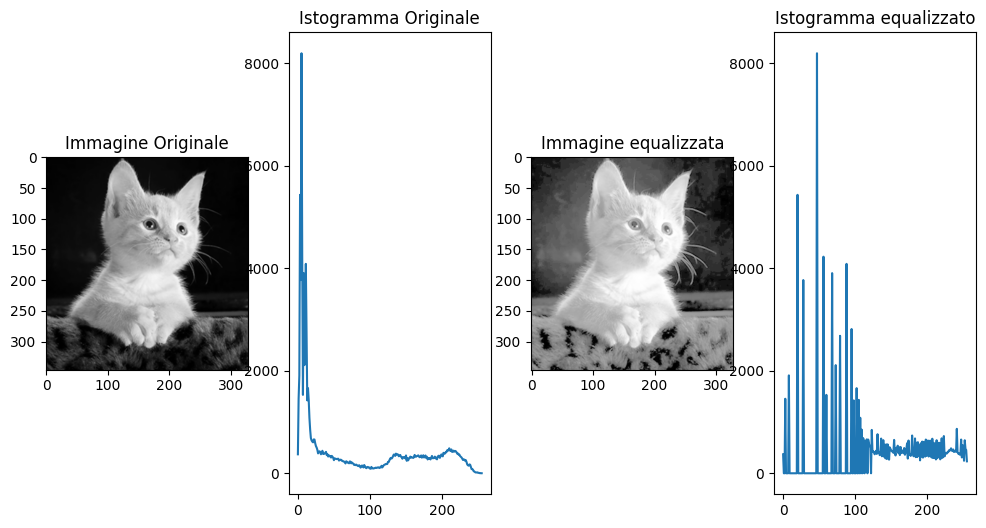

In [ ]:
path = '/content/drive/MyDrive/Computer Vision/gatto.png'
image = cv2.imread(path)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
hist = cv2.calcHist([gray], [0], None, [256], [0, 256]).ravel()

equalized = cv2.equalizeHist(gray)
equalized_hist = cv2.calcHist([equalized], [0], None, [256], [0, 256]).ravel()

plt.figure(figsize=(12, 6))

plt.subplot(1, 4, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Immagine Originale")

plt.subplot(1, 4, 2)
plt.plot(hist)
plt.title('Istogramma Originale')

plt.subplot(1, 4, 3)
plt.imshow(cv2.cvtColor(equalized, cv2.COLOR_BGR2RGB))
plt.title('Immagine equalizzata')

plt.subplot(1, 4, 4)
plt.plot(equalized_hist)
plt.title('Istogramma equalizzato')

plt.show()

## 8: Filtri di smoothing e sharpening
Obiettivo: Applicare diversi filtri di convoluzione e confrontare i risultati

- Carica e Preprocessa l’Immagine:
  - Carica immagine a colori
  - Convertila in scala di grigi
- Applica un filtro di media (blur), un filtro gaussiano, e un filtro Laplaciano.
- Mostra le differenze nei dettagli visibili dell’immagine.

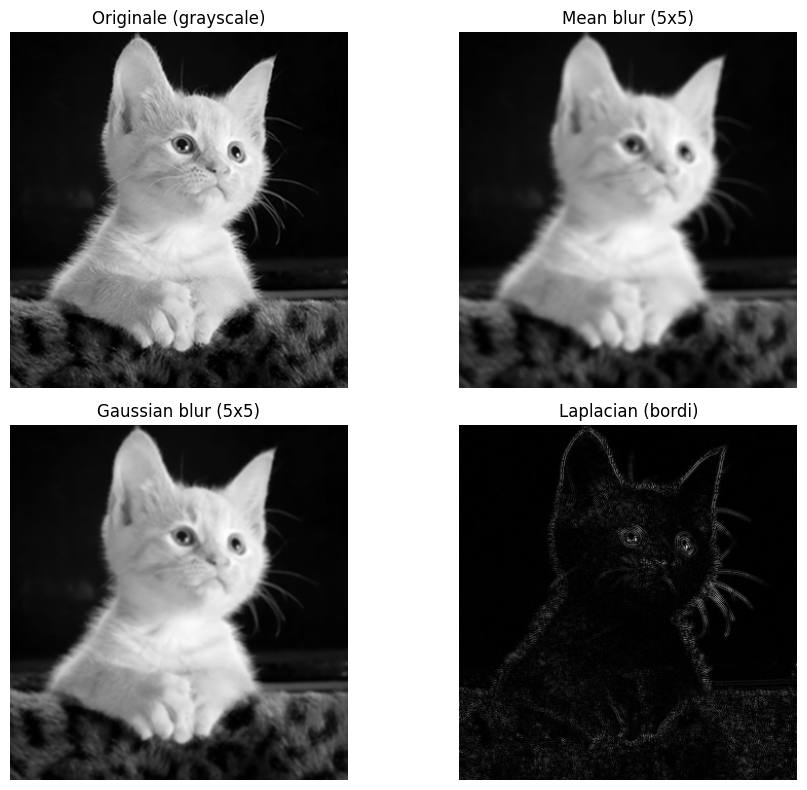

In [ ]:
path = '/content/drive/MyDrive/Computer Vision/gatto.png'
image = cv2.imread(path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# --- Filtri ---
mean_blur: np.ndarray = cv2.blur(gray, (5, 5))   # Filtro di media (blur)
gauss_blur: np.ndarray = cv2.GaussianBlur(gray, (5, 5), 1)  # Filtro gaussiano

# Filtro laplaciano (bordi)
laplacian: np.ndarray = cv2.Laplacian(gray, cv2.CV_64F)
laplacian_abs: np.ndarray = cv2.convertScaleAbs(laplacian)

# --- Visualizzazione ---
plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Originale (grayscale)")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(mean_blur, cmap="gray")
plt.title("Mean blur (5x5)")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(gauss_blur, cmap="gray")
plt.title("Gaussian blur (5x5)")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(laplacian_abs, cmap="gray")
plt.title("Laplacian (bordi)")
plt.axis("off")

plt.tight_layout()
plt.show()